In [23]:
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

In [14]:
iris = load_iris()
dir(iris)


['DESCR',
 'data',
 'data_module',
 'feature_names',
 'filename',
 'frame',
 'target',
 'target_names']

In [24]:
df = pd.DataFrame(iris.data, columns=iris.feature_names)

print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


In [25]:
df = df[['petal length (cm)', 'petal width (cm)']]

print(df.head())

   petal length (cm)  petal width (cm)
0                1.4               0.2
1                1.4               0.2
2                1.3               0.2
3                1.5               0.2
4                1.4               0.2


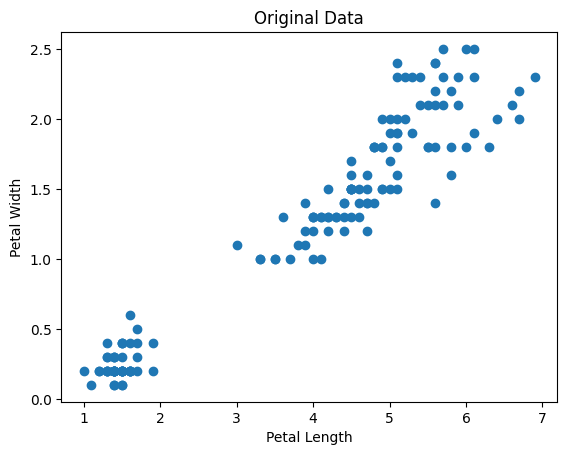

In [26]:
plt.scatter(df['petal length (cm)'],
            df['petal width (cm)'])

plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("Original Data")

plt.show()

In [27]:
scaler = MinMaxScaler()

df_scaled = scaler.fit_transform(df)

print(df_scaled[:5])

[[0.06779661 0.04166667]
 [0.06779661 0.04166667]
 [0.05084746 0.04166667]
 [0.08474576 0.04166667]
 [0.06779661 0.04166667]]


In [28]:
sse = []

k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(df_scaled)

    sse.append(km.inertia_)

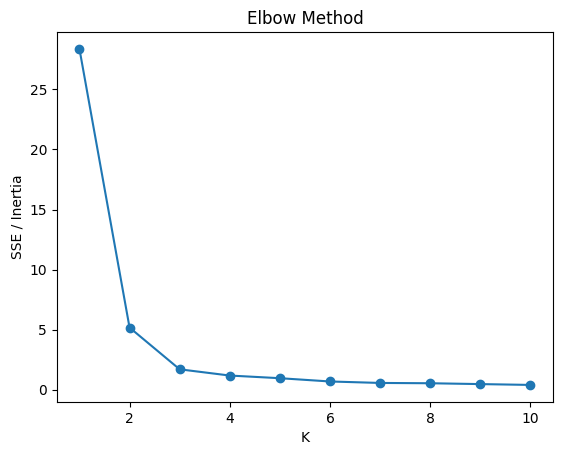

In [29]:
plt.plot(k_range, sse, marker='o')

plt.xlabel("K")
plt.ylabel("SSE / Inertia")
plt.title("Elbow Method")

plt.show()

In [30]:
model = KMeans(n_clusters=3, random_state=42)

predictions = model.fit_predict(df_scaled)

print(predictions)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 2 2 2
 2 2 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 0 0 0 0 0 2 0 0 0 0
 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 2 2 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0]


In [31]:
df['Cluster'] = predictions

print(df.head())

   petal length (cm)  petal width (cm)  Cluster
0                1.4               0.2        1
1                1.4               0.2        1
2                1.3               0.2        1
3                1.5               0.2        1
4                1.4               0.2        1


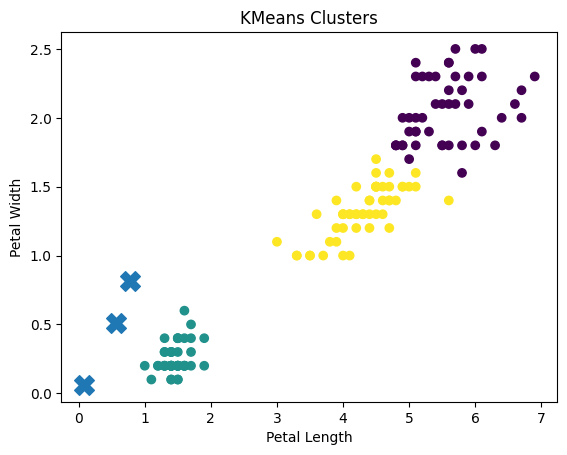

In [32]:
plt.scatter(
    df['petal length (cm)'],
    df['petal width (cm)'],
    c=df['Cluster']
)

# Centroids
centroids = model.cluster_centers_

plt.scatter(
    centroids[:,0],
    centroids[:,1],
    marker='X',
    s=200
)

plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("KMeans Clusters")

plt.show()